In [1]:
# --- [CELL 0]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 1}
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#Model imports
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pd.set_option('display.max_columns',200)
%matplotlib inline

In [2]:
# --- [CELL 1]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 2}
#Loading the data
path="data/For_modeling.csv.zip"

In [3]:
# --- [CELL 2]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 3}
data = pd.read_csv(path, 
                  dtype={
                      'Duration': 'int8',
                      'Distance': 'int8',
                      'PLong': 'float32',
                      'PLatd': 'float32',
                      'DLong': 'float32',
                      'Haversine':'float32',
                      'Pmonth':'int8',
                      'Pday':'int8',
                      'Phour':'int8',
                      'Pmin':'int8',
                      'PDweek':'int8',
                      'Dmonth':'int8',
                      'Dday':'int8',
                      'Dhour':'int8',
                      'Dmin':'int8',
                      'DDweek':'int8',
                      'Temp':'float32',
                      'Precip':'float32',
                      'Wind':'float32',
                      'Solar':'float32',
                      'Snow':'float32',
                      'GroundTemp':'float32',
                      'Dust':'float32'
                  },index_col=0
                  
                  ).sample(frac=1)

#checking for data
data.head(25)

,Duration,Distance,PLong,PLatd,DLong,DLatd,Haversine,Pmonth,Pday,Phour,Pmin,PDweek,Dmonth,Dday,Dhour,Dmin,DDweek,Temp,Precip,Wind,Humid,Solar,Snow,GroundTemp,Dust
8597866,9,70,37.512104,127.107780,37.520451,127.104202,0.980326,11,5,21,23,0,11,5,21,33,0,12.200000,0.0,1.8,79.0,0.00,0.0,9.800000,89.0
6629332,3,64,37.598068,127.039276,37.598270,127.035027,0.375014,9,23,21,51,6,9,23,21,55,6,19.100000,0.0,2.1,38.0,0.00,0.0,15.100000,12.0
8870483,10,84,37.629940,127.076553,37.618320,127.075630,1.294641,11,14,18,31,2,11,14,18,42,2,12.200000,0.0,2.6,47.0,0.01,0.0,9.100000,44.0
8167418,19,54,37.508194,126.891304,37.481602,126.892799,2.959840,10,25,8,32,3,10,25,8,52,3,7.900000,0.0,1.2,76.0,0.25,0.0,6.600000,22.0
8666131,25,-128,37.547070,127.074272,37.591301,127.080330,4.947166,11,7,20,38,2,11,7,21,4,2,13.300000,0.0,1.6,77.0,0.00,0.0,12.700000,43.0
7421279,35,110,37.566223,126.983589,37.585735,127.001610,2.688776,10,9,16,47,1,10,9,17,23,1,19.000000,0.0,1.4,39.0,0.89,0.0,19.600000,28.0
6529165,117,-76,37.534279,126.988564,37.524071,127.021790,3.142137,9,21,15,30,4,9,21,17,28,4,21.799999,0.0,1.4,76.0,1.20,0.0,25.500000,7.0
4264487,23,124,37.605881,127.100632,37.587517,127.052773,4.684934,7,22,12,26,6,7,22,12,52,6,35.500000,0.0,1.9,39.0,3.05,0.0,56.599998,31.0
332542,23,82,37.549202,126.923203,37.556000,126.910454,1.354441,3,2,13,44,4,3,2,14,11,4,2.300000,0.0,3.1,22.0,2.83,0.0,6.500000,103.0
3912733,10,22,37.555367,126.968643,37.536758,126.970001,2.072690,7,13,8,28,4,7,13,8,39,4,25.500000,0.0,1.8,80.0,0.37,0.0,26.600000,12.0


In [4]:
# --- [CELL 3]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 4}
#Resetting index
data = data.reset_index().drop(columns=['index'])
data.head(25)

,Duration,Distance,PLong,PLatd,DLong,DLatd,Haversine,Pmonth,Pday,Phour,Pmin,PDweek,Dmonth,Dday,Dhour,Dmin,DDweek,Temp,Precip,Wind,Humid,Solar,Snow,GroundTemp,Dust
0,9,70,37.512104,127.107780,37.520451,127.104202,0.980326,11,5,21,23,0,11,5,21,33,0,12.200000,0.0,1.8,79.0,0.00,0.0,9.800000,89.0
1,3,64,37.598068,127.039276,37.598270,127.035027,0.375014,9,23,21,51,6,9,23,21,55,6,19.100000,0.0,2.1,38.0,0.00,0.0,15.100000,12.0
2,10,84,37.629940,127.076553,37.618320,127.075630,1.294641,11,14,18,31,2,11,14,18,42,2,12.200000,0.0,2.6,47.0,0.01,0.0,9.100000,44.0
3,19,54,37.508194,126.891304,37.481602,126.892799,2.959840,10,25,8,32,3,10,25,8,52,3,7.900000,0.0,1.2,76.0,0.25,0.0,6.600000,22.0
4,25,-128,37.547070,127.074272,37.591301,127.080330,4.947166,11,7,20,38,2,11,7,21,4,2,13.300000,0.0,1.6,77.0,0.00,0.0,12.700000,43.0
5,35,110,37.566223,126.983589,37.585735,127.001610,2.688776,10,9,16,47,1,10,9,17,23,1,19.000000,0.0,1.4,39.0,0.89,0.0,19.600000,28.0
6,117,-76,37.534279,126.988564,37.524071,127.021790,3.142137,9,21,15,30,4,9,21,17,28,4,21.799999,0.0,1.4,76.0,1.20,0.0,25.500000,7.0
7,23,124,37.605881,127.100632,37.587517,127.052773,4.684934,7,22,12,26,6,7,22,12,52,6,35.500000,0.0,1.9,39.0,3.05,0.0,56.599998,31.0
8,23,82,37.549202,126.923203,37.556000,126.910454,1.354441,3,2,13,44,4,3,2,14,11,4,2.300000,0.0,3.1,22.0,2.83,0.0,6.500000,103.0
9,10,22,37.555367,126.968643,37.536758,126.970001,2.072690,7,13,8,28,4,7,13,8,39,4,25.500000,0.0,1.8,80.0,0.37,0.0,26.600000,12.0


In [5]:
# --- [CELL 4]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 5}
#Dropping value with haversine ==0
data= data[data['Haversine']!=0].reset_index().drop(columns=['index'])
#data.shape

In [6]:
# --- [CELL 5]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 6}
#transforming all the negative distance to posiive distances

data["Distance"]=data['Distance'].apply(lambda x:abs(x))
data[data['Distance']<0].shape

(0, 25)

In [7]:
# --- [CELL 6]: ---
# cell_state: unchanged
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 7}
#Dropping values with diatance is zero, that indicate trip was never occured or error in recordings or something
data = data[data['Distance']!=0].reset_index().drop(columns=['index'])
data[data['Distance']==0].shape

(0, 25)

<ipython-input-8-177cc7d25087>:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  average_duration = data.groupby(data1)['Duration'].mean()


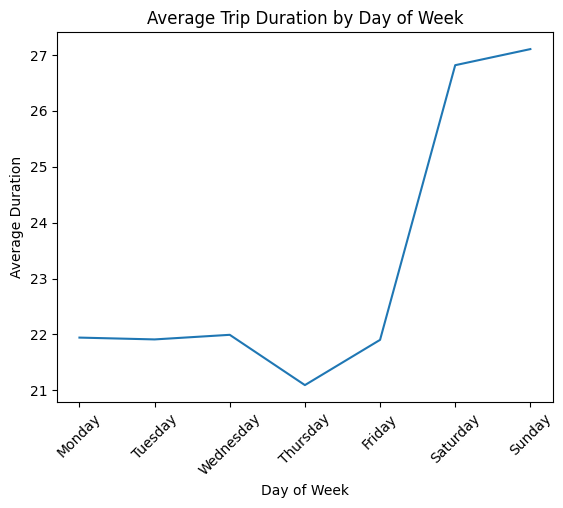

In [8]:
# --- [CELL 7]: ---
# cell_state: edited
# execution_status: {'status': 'ok', 'done': True, 'execution_count': 8}
# === BEFORE (original) ===
# #Average Trip Duration by Day of Week
# # Convert the 'PDweek' column to a day of the week name
# data1= pd.Categorical(data['PDweek'], categories=range(7), ordered=True)
# data1.cat.rename_categories(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], inplace=True)
# 
# # Calculate the average trip duration for each day of the week
# average_duration = data1.groupby('DayOfWeek')['Duration'].mean()
# 
# # Create a line chart
# plt.plot(average_duration.index, average_duration.values)
# plt.xlabel('Day of Week')
# plt.ylabel('Average Duration')
# plt.title('Average Trip Duration by Day of Week')
# plt.xticks(rotation=45)
# plt.show()

# === AFTER (edited) ===
data1 = pd.Series(pd.Categorical(data['PDweek'], categories=range(7), ordered=True), name='DayOfWeek')
data1 = data1.cat.rename_categories(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])

average_duration = data.groupby(data1)['Duration'].mean()

plt.plot(average_duration.index, average_duration.values)
plt.xlabel('Day of Week')
plt.ylabel('Average Duration')
plt.title('Average Trip Duration by Day of Week')
plt.xticks(rotation=45)
plt.show()

In [9]:
# Behavioral test for day-of-week aggregation fix
expected_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
assert 'DayOfWeek' in data.columns, 'Expected DayOfWeek column to be created on data'
assert str(data['DayOfWeek'].dtype) == 'category', 'DayOfWeek should be categorical'
assert list(data['DayOfWeek'].cat.categories) == expected_days, 'DayOfWeek categories should be renamed to weekday names'
assert average_duration.index.name == 'DayOfWeek', 'Aggregation should group by DayOfWeek on data'
assert len(average_duration) == 7, 'Expected one aggregated value per weekday'

AssertionError: Expected DayOfWeek column to be created on data